u [-7.79394327e-15  1.22500000e-03  2.45000000e-03  3.67500000e-03
  4.90000000e-03  6.12500000e-03  7.35000000e-03  8.57500000e-03
  9.80000000e-03  1.10250000e-02  1.22500000e-02  1.34750000e-02
  1.47000000e-02  1.59250000e-02  1.71500000e-02  1.83750000e-02
  1.96000000e-02  2.08250000e-02  2.20500000e-02  2.32750000e-02
  2.45000000e-02  2.57250000e-02  2.69500000e-02  2.81750000e-02
  2.94000000e-02  3.06250000e-02  3.18500000e-02  3.30750000e-02
  3.43000000e-02  3.55250000e-02  3.67500000e-02  3.79750000e-02
  3.92000000e-02  4.04250000e-02  4.16500000e-02  4.28750000e-02
  4.41000000e-02  4.53250000e-02  4.65500000e-02  4.77750000e-02
  4.90000000e-02  5.02250000e-02  5.14500000e-02  5.26750000e-02
  5.39000000e-02  5.51250000e-02  5.63500000e-02  5.75750000e-02
  5.88000000e-02  6.00250000e-02  6.12500000e-02  6.24750000e-02
  6.36000000e-02  6.46250000e-02  6.55500000e-02  6.63750000e-02
  6.71000000e-02  6.77250000e-02  6.82500000e-02  6.86750000e-02
  6.90000000e-02  6.922

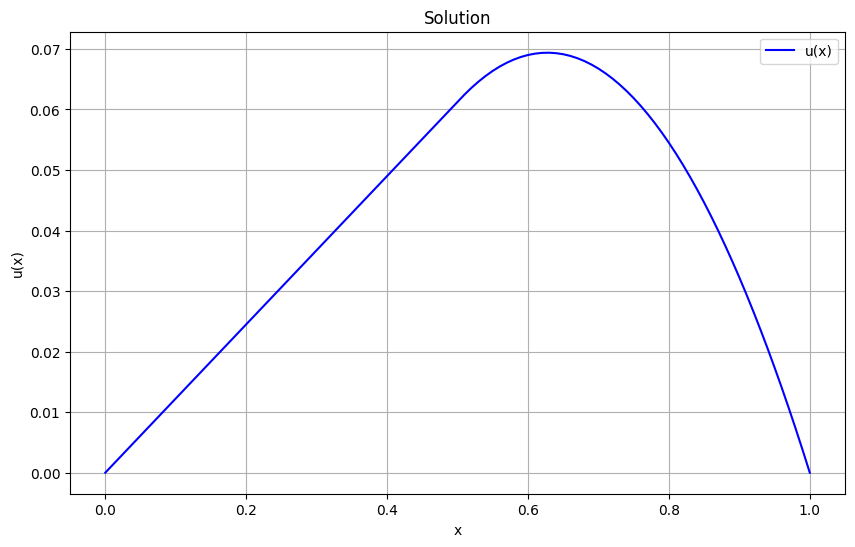

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Функция для вычисления значений f
def func(x) -> float:
    return 0.0 if x <= 0.5 else 1.0 

def A_create(n, h):
    A = np.zeros((n, n))  # Создаем пустую матрицу размера n x n
    for i in range(n):
        A[i, i] = -2
        if i > 0:
            A[i, i-1] = 1
        if i < n-1:
            A[i, i+1] = 1
    return -A / h**2

# Параметры
L = 1
N = 100 
h = L / N
N = 100 + 1

A = A_create(N, h)
f = np.array([func(i*h) for i in range(N)])
g0 = 0
g1 = 0
f[0] = g0
f[-1] = g1
A[-1,:] = 0
A[-1,-1] = 1
A[0,:] = 0
A[0,0] = 1
# Решение для различных значений n
u = np.linalg.solve(A, f)

# Построение графиков
plt.figure(figsize=(10, 6))
plt.plot([i*h for i in range(N)], u, label="u(x)", color="blue")

plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Solution')
plt.legend()
plt.grid()
print("u", u)
print("f", f )
plt.show()


[ 20000001.2 -40000000.   20000000.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.          0.
         0.          0.          0.          0.          0.     

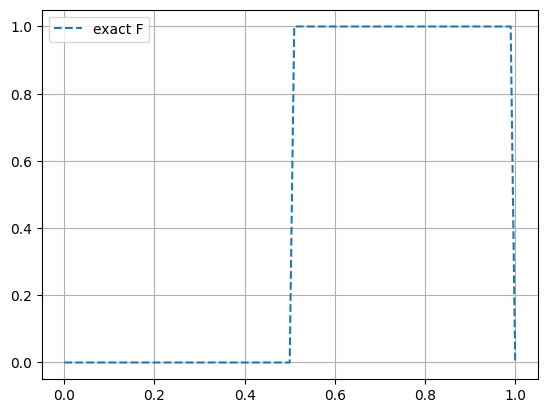

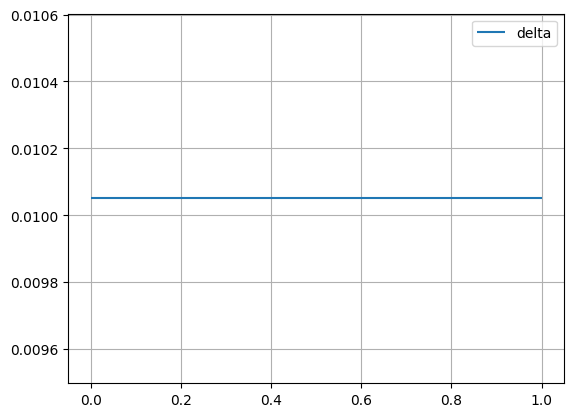

[0.2, 0.1, 0.05, 0.025, 0.0125, 0.00625, 0.003125, 0.0015625, 0.00078125, 0.000390625, 0.0001953125, 9.765625e-05]


In [ ]:
delta = 0.001

#sigma = np.random.rand(N) * 2 - 1.0
sigma = np.random.normal(0, 1, size=N)
u_delta = u + delta * sigma

q = 0.5
alpha0 = 0.2
K = 12
alphas = [q**k * alpha0 for k in range(K)]

residuals = []
f_alphas = []
x = np.linspace(0,L,N)
residuals = []

for alpha in alphas:
    D = A
    E = np.eye(N)
    E_DD = E + alpha * D.T @ D
    Du_delta = D @ u_delta

    for i in range(len(E_DD)):
        for j in range(len(E_DD[i])):
            print(f"{E_DD[i][j]:.2f} " ,end="")
        print()
    break
    f_alpha = np.linalg.solve(E_DD, Du_delta)


    residuals.append(np.linalg.norm(D @ u_delta - f_alpha))
    plt.plot(x,f_alpha, label=f"{alpha}")
    f_alphas.append(f_alpha)
    
plt.plot(x,f, '--', label="exact F")
plt.grid()
plt.legend()
plt.show()
for residual in residuals:
    plt.hlines(y=residual, label="residual",color='r', xmin=x.min(), xmax=x.max())
plt.hlines(y=delta*np.sqrt(N), label="delta", xmin=x.min(), xmax=x.max())
plt.legend()
plt.grid()
plt.show()


print(alphas)


Условия остановки при |u_f - u_delta|<eps: eps=0.01005
невязка при i=250: 	0.07110
невязка при i=500: 	0.03418
невязка при i=750: 	0.02000
невязка при i=1000: 	0.01358
невязка при i=1250: 	0.01106
невязка при i=1500: 	0.01016
Достиг условия остановки 1555: 0.01005
Прошло 0.621 секунд


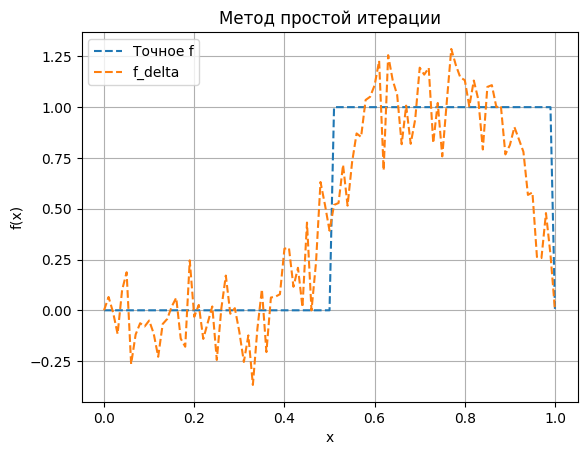

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import time
# Предполагаемые данные
x = np.linspace(0, L, N)
D = A  # Матрица D (например, дискретизация оператора)
u_delta = u + delta * sigma # Зашумленные данные


eig_values, eig_vector = np.linalg.eig(A)
# Параметры метода
tau = 0.1
# Инициализация
f_current = np.zeros(N)
f_alphas = []

D_inv = np.linalg.inv(D)
print(f"Условия остановки при |u_f - u_delta|<eps: eps={delta*np.sqrt(N):.5f}")
start_time = time.time()
# Итерационный процесс
i = 0
A_ = -1 / h**2
B_ = 2 / h**2
C_ = -1 / h**2

u_f = np.zeros(N)
alpha = np.zeros((N))
beta = np.zeros((N))

while True:
    f_new = f_current + tau * (u_delta - D_inv @ f_current)

    for j in range(1, N-1):
        alpha[j+1]= ( - C_ / ((A_) * alpha[j] + B_) )
        beta[j+1] = ( ( f_new[j] - (A_) * beta[j]) / (A_*alpha[j] + B_) )
    u_f[N-1] = 0 
    for j in range(N-2, 0, -1):
        u_f[j] = alpha[j+1]* u_f[j+1] + beta[j+1]

    if (i+1) % 250 == 0:
        print(f"невязка при i={i+1}: \t{np.linalg.norm(u_f - u_delta):.5f}")
    
    if np.linalg.norm(u_f - u_delta) < delta*np.sqrt(N):
        print(f"Достиг условия остановки {i}: {np.linalg.norm(u_f - u_delta):.5f}")
        break
    if (i > 3000):
        print("Достиг максимального кол-ва итераций")
        break
    f_current = f_new
    i += 1
print(f"Прошло {(time.time() - start_time):.3f} секунд")

plt.plot(x, f, '--', label="Точное f")
plt.plot(x, f_current, '--', label="f_delta")
plt.grid()
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Метод простой итерации")
plt.show()

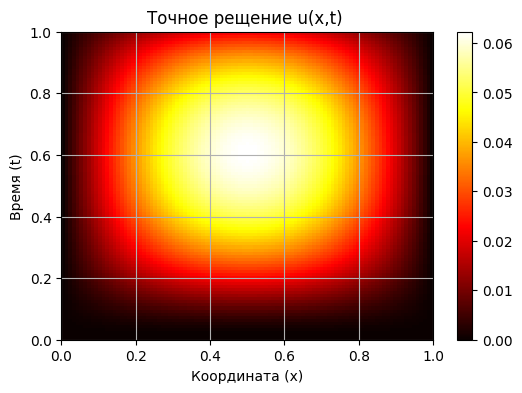

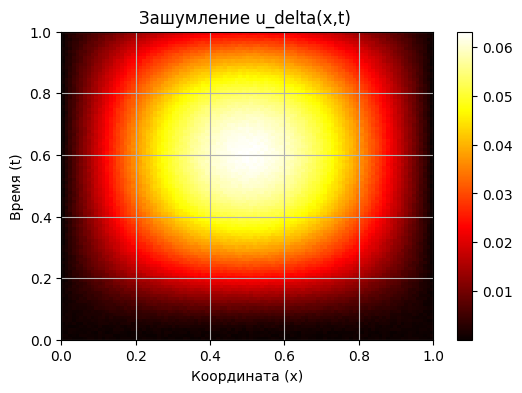

0.1


  0%|          | 0/2000 [00:00<?, ?it/s]

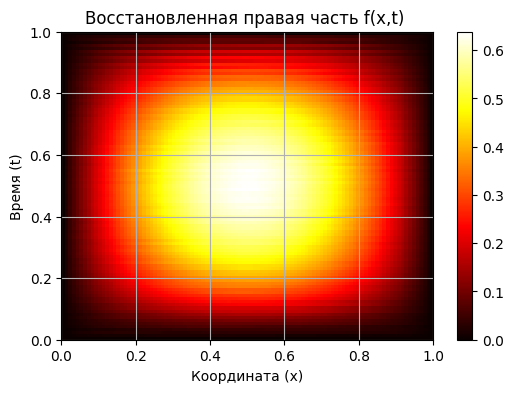

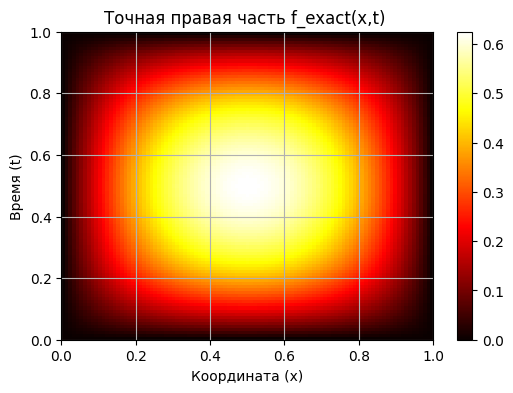

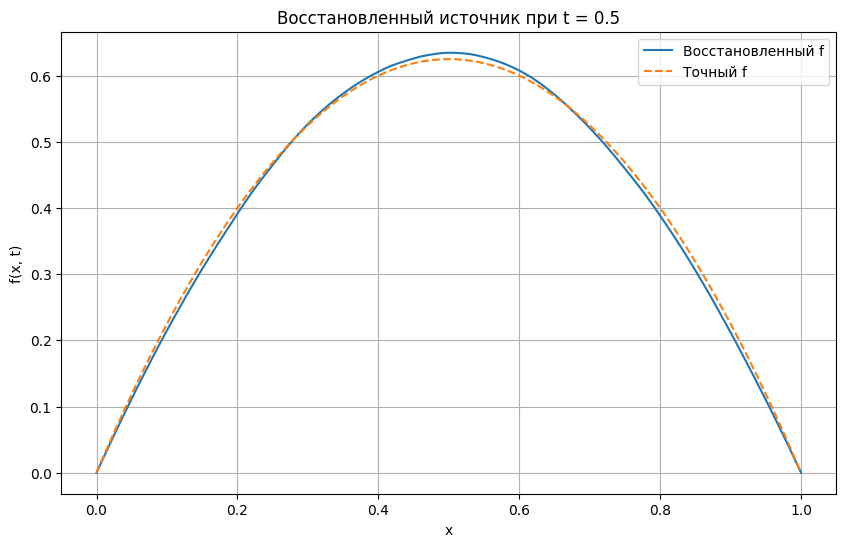

Ошибка восстановления при t = 0.5: 0.082288


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def maps(value, titles):
    fig, ax1 = plt.subplots(figsize=(6, 4))
    im1 = ax1.imshow(value, extent=[ 0, L, 0, T], aspect='auto', cmap='hot', origin='lower', interpolation='nearest')
    ax1.set_ylabel("Время (t)"); ax1.set_xlabel("Координата (x)"); ax1.set_title(f"{titles}(x,t) "); ax1.grid(True)
    fig.colorbar(im1, ax=ax1, orientation='vertical')
    plt.show()



def Norm(x):
    return np.sqrt(np.sum(x**2))

# Источник
def f(x, t):
    return 10 * t * (1 - t) * x * (1 - x)

# Параметры
L = 1.0                         # Длина пространственной области
T = 1.0                         # Длина временной области
N = 100                         # Число пространственных точек
M = 100                         # Число временных точек
h = L / (N)                     # Шаг по пространству
tau = T / (M)                   # Шаг по времени
x = np.linspace(0, L, N+1)      # Пространственная сетка
t = np.linspace(0, T, M+1)      # Временная сетка

u = np.zeros((M+1, N+1))
u[0, :] = 0  # Начальное условие

# Вычисление источника
f_values = np.zeros((M+1, N+1))
for j in range(M):
    for i in range(N):
        f_values[j, i] = f(x[i], t[j])

A = -1 / h**2
B = 2 / h**2 + 1 / tau
C = -1 / h**2
# Метод прогонки для прямой задачи
for j in range(M):
    alpha = np.zeros((N+1)); beta = np.zeros((N+1)); 
    alpha[0] = 0; beta[0] = 0
    for i in range(1, N):
        alpha[i+1]= ( -C / (A * alpha[i] + B) )
        beta[i+1] = ( ( u[j][i] / tau +  f_values[j][i] - A*beta[i]) / (A*alpha[i] + B) )
    u[j][N] = 0 
    for i in range(N-1, 0, -1):
        u[j+1][i] = alpha[i+1]* u[j+1][i+1] + beta[i+1]

maps(u, "Точное рещение u")

# Зашумление данных
delta = 0.001
sigma = np.random.uniform(0, 1, size=(M+1, N+1))
u_delta = u + delta * sigma 
maps(u_delta,"Зашумление u_delta")
y_delta = np.zeros((M+1, N+1))

# Шаг по времени для прямой сопреженной задачи
for j in range(M-1, 0, -1):
    alpha = np.zeros((N+1)); beta = np.zeros((N+1)); 
    alpha[0] = 0; beta[0] = 0
    for i in range(1,N):
        alpha[i+1]= ( -C / (A * alpha[i] + B) )
        beta[i+1] = ( ( - y_delta[j+1][i] / tau + u_delta[j+1][i] - A*beta[i]) / (A*alpha[i] + B) )
    y_delta[j][N] = 0
    for i in range(N-1, 0, -1):
        y_delta[j][i] = alpha[i+1]* y_delta[j][i+1] + beta[i+1]




# Восстановление f для всех временных шагов
f_restored = np.zeros((M+1, N+1))

v = np.zeros((M+1, N+1))
w = np.zeros((M+1, N+1))
rk = np.zeros((M+1, N+1))
Grk = np.zeros((M+1, N+1))
fk = np.zeros((M+1, N+1))
fk[:][0] = fk[:][-1] = 0

print(delta * np.sqrt(N)*np.sqrt(M))

pbar = tqdm(range(2000))
for k in pbar:

    # Прямая задача: v = G f_k
    for j in range(M):
        alpha = np.zeros(N+1); beta = np.zeros(N+1)
        for i in range(1, N):
            alpha[i+1] = -C / (A * alpha[i] + B)
            beta[i+1] = (v[j][i] / tau + fk[j][i] - A * beta[i]) / (A * alpha[i] + B)
        v[j+1][N] = 0
        for i in range(N-1, 0, -1):
            v[j+1][i] = alpha[i+1] * v[j+1][i+1] + beta[i+1]

    # Сопряжённая задача: w = G^* v
    for j in range(M-1, 0, -1):
        alpha = np.zeros(N+1); beta = np.zeros(N+1)
        for i in range(1, N):
            alpha[i+1] = -C / (A * alpha[i] + B)
            beta[i+1] = (- w[j+1][i] / tau + v[j+1][i] - A * beta[i]) / (A * alpha[i] + B)
        w[j][N] = 0
        for i in range(N-1, 0, -1):
            w[j][i] = alpha[i+1] * w[j][i+1] + beta[i+1]

    # Остаток
    rk = w - y_delta

    # Прямая задача: Grk = G r_k
    for j in range(M):
        alpha = np.zeros(N+1); beta = np.zeros(N+1)
        for i in range(1,N):
            alpha[i+1] = - C / (A * alpha[i] + B)
            beta[i+1] = (Grk[j][i] / tau + rk[j][i] - A * beta[i]) / (A * alpha[i] + B)
        Grk[j+1][N] = 0
        for i in range(N-1, 0, -1):
            Grk[j+1][i] = alpha[i+1] * Grk[j+1][i+1] + beta[i+1]

    # Шаг итерации
    tau_k = Norm(rk) / Norm(Grk)
    fk_new = fk - tau_k * rk

    error = Norm(v - u_delta)
    # Критерий остановки
    if error <= delta * np.sqrt(N)*np.sqrt(M):
        fk = fk_new
        break
    
    pbar.set_description(f"tau: {tau_k:.6f} fk_mean: {fk.mean():.6f}  error: {error:.6f}")
    fk = fk_new

maps(fk, "Восстановленная правая часть f")
maps(f_values, "Точная правая часть f_exact")

# Сравнение на t = 0.5
plt.figure(figsize=(10, 6))
plt.plot(x, fk[M//2], label='Восстановленный f')
plt.plot(x, f_values[M//2], '--', label='Точный f')
plt.xlabel('x')
plt.ylabel('f(x, t)')
plt.title('Восстановленный источник при t = 0.5')
plt.legend()
plt.grid(True)
plt.show()

# Ошибка восстановления
error = np.linalg.norm(fk[M//2] - f_values[M//2])
print(f"Ошибка восстановления при t = 0.5: {error:.6f}")